In [153]:
import os
import xarray as xr
import functions.MLD_4grp_cmip as fl_mld
import matplotlib.pyplot as plt
import gsw
import numpy as np
import functions.mld_calculations as cmip_mld
from multiprocessing import Pool
import re


In [162]:
# directories

data_dir = "/Users/smb-uh/UHM_Ocean_BGC_Group Dropbox/Datasets/"
cmip_dir = data_dir + "Model_Output/CMIP5/"

model_run = 'cmip5'
# model_run = 'cmip6_historical'
# model_run = 'cmip6_ssp585'

if model_run=='cmip5':
    cmip_dir = data_dir + "Model_Output/CMIP5/"
    experiment = 'rcp85'
    dir_add_on = ''
elif model_run=='cmip6_historical':
    cmip_dir = data_dir + "Model_Output/CMIP6/"
    experiment = 'historical'
    dir_add_on = 'historical_download/'
elif model_run=='cmip6_ssp585':
    cmip_dir = data_dir + "Model_Output/CMIP6/"
    experiment = 'ssp585'
    dir_add_on = 'historical_download/'


In [160]:
so_file_list = []
out_dir = 'mld/regrid/'

for file in os.listdir(cmip_dir + 'so/regrid_for_MLD/' + dir_add_on):
    if file.endswith('.nc'):
        so_file_list.append(file)


# print(so_file_list)
# get a list of model names
unique_model_names = set()


# Regular expression to find the pattern
pattern = re.compile(r'Omon_(.*?)_'+experiment)

# Extract the text between "Omon_" and "_rcp85"
for file_name in so_file_list:
    match = pattern.search(file_name)
    if match:
        unique_model_names.add(match.group(1))

# Convert the set to a list
unique_values_list = list(unique_model_names)

# Print the unique values
print(unique_values_list)

['IPSL-CM5A-MR', 'MRI-ESM1', 'GISS-E2-H-CC', 'CanESM2', 'MIROC-ESM-CHEM', 'HadGEM2-ES', 'NorESM1-ME', 'CNRM-CM5', 'CMCC-CESM', 'HadGEM2-CC', 'MPI-ESM-MR', 'MPI-ESM-LR', 'GFDL-ESM2M', 'GFDL-ESM2G', 'CESM1-BGC', 'IPSL-CM5B-LR', 'GISS-E2-R-CC']


In [29]:
# print(so_file_list)
# print(thetao_file_list)

['so_Omon_CanESM2_rcp85_r1i1p1_200601-202012.nc']
['thetao_Omon_CanESM2_rcp85_r1i1p1_200601-202012.nc']


In [182]:
from importlib import reload
reload(cmip_mld)


num_processes = 20

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        mld_args = [(cmip_dir, out_dir, model, dir_add_on) for n, model in enumerate(unique_values_list)]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(cmip_mld.cmip_mld_calc, mld_args)


# cmip_mld.cmip_mld_calc(cmip5_dir, out_dir, so_file_list[0], thetao_file_list[0])

In [148]:
so_n = xr.open_dataset(cmip5_dir + 'so/regrid_for_MLD/' + so_file_list[0])
# thetao_n = xr.open_dataset(cmip5_dir + 'thetao/regrid_for_MLD/' + 'thetao' + so_file_list[0][2:-1])
thetao_n = xr.open_dataset(cmip5_dir + 'thetao/regrid_for_MLD/' + thetao_file_list[0])

In [63]:
def sigma0(salinity,temperature,lon,lat,pressure):
    SA = gsw.SA_from_SP(salinity,
                        pressure,
                        lon,
                        lat)

    CT = gsw.CT_from_t(SA,
                       temperature,
                       pressure)

    sigma = gsw.sigma0(SA,CT)
    
    return sigma

In [178]:
from importlib import reload
reload(fl_mld)
sig_threshold = 0.03

mld_array = np.zeros((len(thetao_n['lon']), len(thetao_n['lat']), len(thetao_n['time'])))
mld_array[:] = np.NaN
# la = 30

for tt in range(0, len(thetao_n['time'])):
    for lo in range(0,360):
        for la in range(10, 60):
            if sum(~np.isnan(so_n['so'].isel(time=tt, lon=lo, lat=la).values))==0:
                continue
            pot_dens = sigma0(so_n['so'].isel(time=tt, lon=lo, lat=la).values, 
                            thetao_n['thetao'].isel(time=tt, lon=lo, lat=la).values-273.15, 
                            thetao_n['lon'][lo].values, thetao_n['lat'][la].values, thetao_n['lev'].values)
            
            mld = fl_mld.calc_mld(pot_dens, thetao_n['lev'].values, ref_depth=10, sigma_theta_crit=sig_threshold)
            mld_array[lo, la, tt] = mld

KeyboardInterrupt: 

In [175]:
ds = xr.Dataset({})
ds['thetao'] = thetao_n['thetao']
ds['mld'] = (('lon', 'lat', 'time'), mld_array)
ds['mld'] = ds['mld'].assign_attrs(units="m",long_name='MLD calculated from monthly output, 0.03 sig theta from 10 m')

d_mld_only = ds.drop_vars('thetao')
# d_mld_only.to_netcdf(cmip_dir + 'mld/regrid/' + 'mld' + so_file_list[0][2:])

In [177]:
ds

<xarray.Dataset>
Dimensions:  (time: 120, lon: 360, lat: 180, lev: 40)
Coordinates:
  * time     (time) object 2010-01-16 12:00:00 ... 2019-12-16 12:00:00
  * lon      (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 355.0 356.0 357.0 358.0 359.0
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lev      (lev) float64 2.5 10.0 20.0 30.0 40.0 ... 650.0 700.0 750.0 800.0
Data variables:
    thetao   (time, lev, lat, lon) float32 ...
    mld      (lon, lat, time) float64 nan nan nan nan nan ... nan nan nan nan

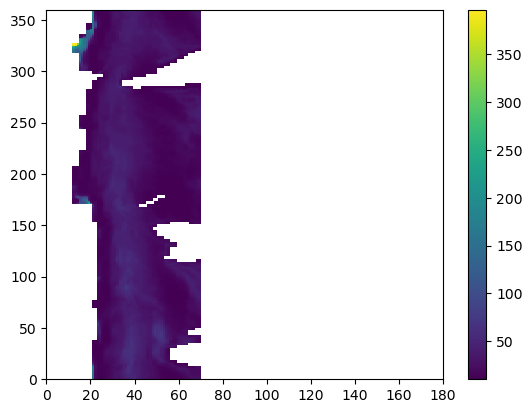

In [94]:
plt.pcolor(mld_array[:,:,0])
plt.colorbar()

In [17]:
print(so_n)
print(thetao_n)

<xarray.Dataset>
Dimensions:    (time: 120, bnds: 2, lon: 360, lat: 180, lev: 31)
Coordinates:
  * time       (time) datetime64[ns] 2010-01-16T12:00:00 ... 2019-12-16T12:00:00
  * lon        (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat        (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lev        (lev) float64 5.0 15.0 20.0 25.0 30.0 ... 700.0 800.0 900.0 1e+03
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    so         (time, lev, lat, lon) float32 ...
Attributes: (12/30)
    CDI:                    Climate Data Interface version 2.1.1 (https://mpi...
    Conventions:            CF-1.4
    source:                 CMCC-CESM
    institution:            CMCC - Centro Euro-Mediterraneo per i Cambiamenti...
    institute_id:           CMCC
    experiment_id:          rcp85
    ...                     ...
    title:                  CMCC-CESM model output prepared for CMIP5 RCP8.5
    paren

In [ ]:
plt.

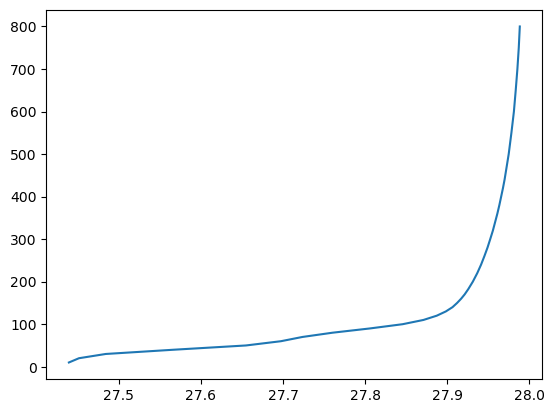

In [66]:
plt.plot(pot_dens, thetao_n['lev'].values)